# Segmentace telekomunikačních účastníků shlukováním metodou k-průměrů


## Shrnutí

Telekomunikační operátor chce rozdělit svou paušální zákaznickou základnu do chování odpovídajících segmentů, aby mohl cílit retenční nabídky a správně nastavit datové tarify. Tento notebook vygeneruje syntetický datový soubor o využívání služeb účastníky a poté spustí kompletní segmentační proces metodou k-průměrů v Base SAS: standardizuje vstupní proměnné pomocí **PROC STDIZE**, zvolí počet shluků porovnáním pseudo-F statistiky napříč kandidátními k pomocí **PROC FASTCLUS**, sestaví finální model vážený pomocí FREQ, který ohodnotí každého účastníka, a exportuje naučené centroidy, aby bylo možné příští měsíční snímek ohodnotit bez opětovného shlukování. Výsledkem je znovupoužitelná segmentace, která mapuje syrovou telemetrii využívání na retenční playbook.


## Zdroje dat

**Syntetický datový soubor: `WORK.SUBSCRIBERS`** (100 paušálních mobilních účastníků, vygenerováno přímo pomocí `call streaminit(20260531)`)

| Proměnná | Typ | Role | Popis |
|----------|------|------|-------------|
| `cust_id` | Znak | ID | Identifikátor účastníka (např. `SUB000123`) |
| `tenure_months` | Číslo | Vstup (interval) | Počet měsíců, po které je linka aktivní (1-72) |
| `data_gb` | Číslo | Vstup (interval) | Průměrná měsíční spotřeba mobilních dat v GB |
| `voice_min` | Číslo | Vstup (interval) | Průměrný počet hlasových minut za měsíc |
| `intl_min` | Číslo | Vstup (interval) | Průměrný počet mezinárodních minut za měsíc |
| `support_calls` | Číslo | Vstup (interval) | Kontakty se zákaznickou podporou za posledních 90 dní |
| `monthly_charge` | Číslo | Vstup (interval) | Aktuální měsíční vyúčtování v dolarech |
| `plan_tier` | Znak | Profilování | Tarifní úroveň: `Základní`, `Plus` nebo `Neomezený` |
| `n_lines` | Číslo | Váha FREQ | Počet linek na účtu |

Do generátoru jsou vloženy tři skryté chování odpovídající profily - *úsporný/hodnotový*, *datově náročný/streamující* a *kontaktní/rizikový* - takže shlukování má reálnou strukturu, kterou lze odhalit. Intervalové proměnné vstupují do modelu k-průměrů; `plan_tier` je vyloučen z modelu a slouží k následnému profilování a `n_lines` váží každý účet podle počtu jeho linek. Nepoužívají se žádné externí soubory ani síťový přístup.


## Segmentace chování v pěti krocích

Mobilní operátoři spravují miliony paušálních linek a univerzální retenční strategie plýtvá marží u zákazníků, kteří by zůstali tak jako tak, zatímco přehlíží ty, kteří brzy odejdou. **Segmentace chování** přemění syrovou telemetrii využívání na několik akceschopných typů zákazníků: *úsporné/hodnotové* uživatele citlivé na cenu, *datově náročné streamery*, kteří jsou dobrým cílem pro upsell, a *kontaktní/rizikové* účty, které potřebují proaktivní péči.

Tento notebook sestavuje segmentaci pomocí `PROC FASTCLUS`, procedury SAS pro k-průměry (disjunktní shlukování). Provedeme:

1. Vygenerování syntetického, ale realistického datového souboru o využívání služeb účastníky.
2. Převedení vstupních proměnných na společné měřítko pomocí **PROC STDIZE**.
3. **Volbu počtu shluků** porovnáním pseudo-F statistiky napříč kandidátními k.
4. Sestavení finálního modelu váženého pomocí FREQ, který **ohodnotí** každého účastníka a profiluje segmenty.
5. **Export naučených centroidů**, aby bylo možné model znovu použít na příští měsíční snímek.


## Krok 1 - Vygenerování syntetické základny účastníků

Simulujeme 100 paušálních účastníků. Každý je vygenerován z jednoho ze tří skrytých profilů s odlišnými vzorci využívání, takže existuje skutečná shluková struktura, kterou lze odhalit. Proud náhodných čísel ustálíme pomocí `call streaminit` kvůli reprodukovatelnosti a simulované hodnoty omezíme na věrohodné rozsahy pomocí `max`/`min`/`round`.

Nominální proměnná `plan_tier` je korelována se skrytým profilem (streameři inklinují k *Neomezený*; hodnotoví uživatelé k *Základní*) a `n_lines` bude později sloužit jako váha FREQ, aby se vícelinkové rodinné účty počítaly úměrně.


In [1]:
data subscribers;
    CALL streaminit(20260531);
    DÉLKA cust_id $9 plan_tier $20;
    OPAKUJ i = 1 TO 100;
        cust_id = cats('SUB', ZAPSAT(i, z6.));

        /* Three latent behavioral profiles, ~unequal prevalence */
        u = rand('uniform');
        KDYŽ u < 0.45 PAK profile = 1;        /* light / value        */
        JINAK KDYŽ u < 0.80 PAK profile = 2;   /* heavy-data streamer   */
        JINAK profile = 3;                    /* high-touch / at-risk  */

        KDYŽ profile = 1 PAK OPAKUJ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        KONEC;
        JINAK KDYŽ profile = 2 PAK OPAKUJ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        KONEC;
        JINAK OPAKUJ;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        KONEC;

        /* Plan tier correlated with profile */
        p = rand('uniform');
        KDYŽ profile = 1 PAK
            plan_tier = ifc(p < 0.70, 'Základní', ifc(p < 0.95, 'Plus', 'Neomezený'));
        JINAK KDYŽ profile = 2 PAK
            plan_tier = ifc(p < 0.65, 'Neomezený', ifc(p < 0.90, 'Plus', 'Základní'));
        JINAK
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Neomezený', 'Základní'));

        /* Lines on the account: most are single-line */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Round monetary / usage values to realistic precision */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        VÝSTUP;
    KONEC;
    ODSTRANIT i u p profile;
SPUSTIT;

PROCEDURA TISK data=subscribers(obs=10) noobs;
    ŠTÍTEK cust_id='ID účastníka' tenure_months='Doba trvání (měsíce)' data_gb='Data (GB)'
          voice_min='Hlasové minuty' intl_min='Mezinárodní minuty' support_calls='Kontakty s podporou'
          monthly_charge='Měsíční poplatek' plan_tier='Tarifní úroveň' n_lines='Počet linek';
    NÁZEV 'Ukázka syntetických záznamů o využívání účastníky';
SPUSTIT;


                                   Ukázka syntetických záznamů o využívání účastníky                                    

   ID účastníka     Tarifní úroveň      Doba trvání (měsíce)  Data (GB)   Hlasové minuty    Mezinárodní minuty  Kontakty s podporou      Měsíční poplatek   Počet linek
SUB000001        Základní                                 15        9.7              114                     5                   11                 57.07             2
SUB000002        Základní                                 39        0.6              214                     2                    1                 35.88             3
SUB000003        Neomezený                                45       23.9              325                     6                    1                103.94             2
SUB000004        Základní                                 41        1.9              202                     1                    0                 61.69             3
SUB000005        Základní             


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Krok 2 - Převedení vstupních proměnných na společné měřítko

Metoda k-průměrů používá euklidovskou vzdálenost, takže proměnná s velkým rozsahem hodnot, jako jsou hlasové minuty, by při shlukování na surových hodnotách převážila proměnnou s malým rozsahem, jako jsou kontakty s podporou. Standardním řešením je nejprve standardizovat všechny intervalové proměnné na průměr 0 a směrodatnou odchylku 1. **PROC STDIZE** s `METHOD=STD` přesně toto provádí a zapisuje standardizovanou kopii do `WORK.SUBS_STD`. Proměnné `cust_id`, `plan_tier` a `n_lines` přenášíme beze změny, aby byly později k dispozici pro vážení a profilování.


In [2]:
PROCEDURA stdize data=subscribers out=subs_std METHOD=std;
    PROMĚNNÁ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
SPUSTIT;

PROCEDURA PRŮMĚRY data=subs_std mean std maxdec=3;
    PROMĚNNÁ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ŠTÍTEK tenure_months='Doba trvání (měsíce)' data_gb='Data (GB)' voice_min='Hlasové minuty'
          intl_min='Mezinárodní minuty' support_calls='Kontakty s podporou' monthly_charge='Měsíční poplatek';
    NÁZEV 'Standardizované proměnné: průměr ~ 0, směrodatná odchylka ~ 1';
SPUSTIT;


                                   Ukázka syntetických záznamů o využívání účastníky                                    

                             Standardizované proměnné: průměr ~ 0, směrodatná odchylka ~ 1                              

                                                  The MEANS Procedure

 Variable        Label                              Mean     Std Dev
 -------------------------------------------------------------------
 tenure_months   Doba trvání (měsíce)              0.000       1.000
 data_gb         Data (GB)                        -0.000       1.000
 voice_min       Hlasové minuty                   -0.000       1.000
 intl_min        Mezinárodní minuty                0.000       1.000
 support_calls   Kontakty s podporou              -0.000       1.000
 monthly_charge  Měsíční poplatek                  0.000       1.000
 -------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 3 - Kolik segmentů? Porovnání pseudo-F statistiky napříč kandidátními k

Namísto hádání počtu shluků spustíme FASTCLUS pro každé kandidátní k a odečteme statistiky shody modelu, které procedura hlásí. **Pseudo-F statistika** (poměr meziskupinového a vnitroskupinového rozptylu) i **celkové R-kvadrát** odměňují oddělenost; dobré k je tam, kde je pseudo-F vysoké a přidání dalšího shluku přináší klesající přínos. Krátká makro smyčka spustí k = 2, 3, 4 s `MAXITER=50` a `CONVERGE=0` (iterovat do ustálení). Porovnejte řádky `Pseudo F Statistic` a `Overall R-Squared` ve třech výpisech níže: vložená struktura má tři skryté profily a k = 3 dává nejsilnější a nejvyváženější řešení.


In [3]:
%macro pick_k;
    %OPAKUJ k = 2 %TO 4;
        PROCEDURA FASTCLUS data=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            PROMĚNNÁ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            NÁZEV "Kandidátní počet shluků: k = &k";
        SPUSTIT;
    %KONEC;
%mend pick_k;
%pick_k;


                             Standardizované proměnné: průměr ~ 0, směrodatná odchylka ~ 1                              


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Krok 4 - Sestavení finální segmentace a ohodnocení každého účastníka

S vybraným k = 3 sestavíme produkční model. Tento běh je plně idiomatický pro provozní segmentaci:

- Příkaz `FREQ` váží každý účet podle `n_lines`, takže čtyřlinkový rodinný účet přispívá čtyřikrát více než jedna linka při výpočtu centroidů.
- `OUT=SCORED` zapíše každého účastníka s jeho přiřazeným `CLUSTER` a jeho `DISTANCE` k centroidu tohoto shluku; příkaz `ID` přenese `cust_id` do této ohodnocené tabulky.
- `MEAN=SEG_MEANS` zachytí centroidy jednotlivých shluků (na standardizovaném měřítku).
- `OUTSEED=SEG_SEEDS` uloží finální centroidy ve formátu seed, který FASTCLUS umí zpětně načíst - toto je exportovaný model, který znovu použijeme v kroku 6.

Statistiky shody modelu už byly stanoveny v přehledu z kroku 3, takže zde přidáváme volbu `SHORT`, aby výpis zůstal zaměřen na velikosti shluků a centroidy, které řídí výstup ohodnocení.


In [4]:
PROCEDURA FASTCLUS data=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    PROMĚNNÁ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ČETNOSTI n_lines;
    id cust_id;
    NÁZEV 'Finální segmentace: k = 3, vážená podle FREQ počtem linek';
SPUSTIT;

PROCEDURA TISK data=seg_means noobs;
    NÁZEV 'Centroidy segmentů (standardizované měřítko)';
SPUSTIT;


                             Standardizované proměnné: průměr ~ 0, směrodatná odchylka ~ 1                              


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Krok 5 - Profilování segmentů v obchodních jednotkách

Ohodnocená tabulka nese přiřazení `CLUSTER` každého účastníka, ale na standardizovaném měřítku se centroidy obtížně čtou. Abychom proměnili čísla shluků na obchodní persony, spojíme přiřazení zpět s původní tabulkou `subscribers` a profilujeme na reálných jednotkách - gigabajtech, minutách a dolarech. PROC MEANS shrnuje intervalové proměnné podle segmentu a PROC FREQ křížově tabuluje vyloučenou proměnnou `plan_tier` proti segmentu, aby ukázal tarifní mix každé persony.


                          Profily segmentů: průměrné využívání podle shluku (původní jednotky)                          

                                                  The MEANS Procedure

                              Analysis Variable : tenure_months Doba trvání (měsíce)

                                        N
                             Shluk    Obs      Mean      Std Dev      Minimum      Maximum
                             -------------------------------------------------------------
                             1         51      33.2         14.7          1.0         61.0
                             2         31      40.5         14.0         17.0         67.0
                             3         18      12.7          7.1          1.0         30.0
                             -------------------------------------------------------------

                                        Analysis Variable : data_gb Data (GB)

                                        N
           


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


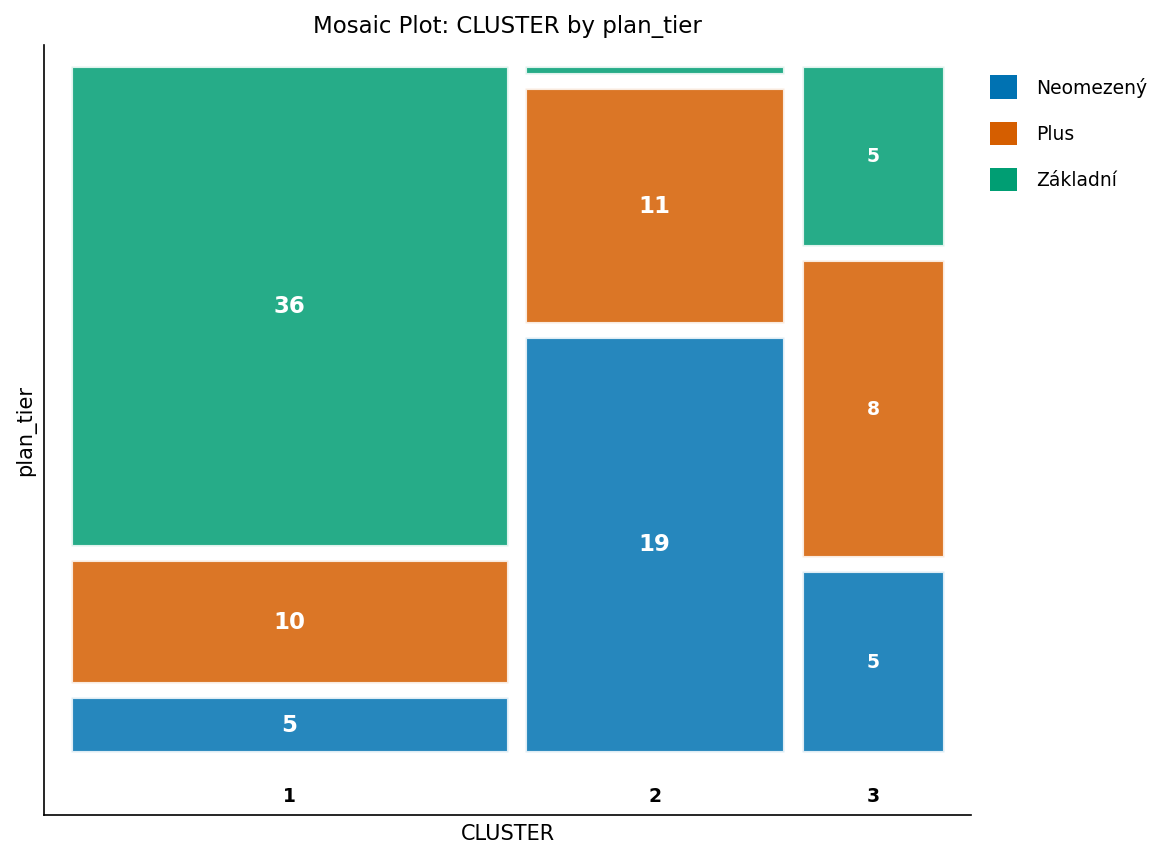

In [5]:
PROCEDURA ŘADIT data=scored out=scored_keys(PONECHAT=cust_id CLUSTER);
    PODLE cust_id;
SPUSTIT;

PROCEDURA ŘADIT data=subscribers out=subs_sorted;
    PODLE cust_id;
SPUSTIT;

data profile;
    SLOUČIT subs_sorted(IN=a) scored_keys(IN=b);
    PODLE cust_id;
    KDYŽ a AND b;
SPUSTIT;

PROCEDURA PRŮMĚRY data=profile mean std MIN MAX maxdec=1;
    TŘÍDA CLUSTER;
    PROMĚNNÁ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ŠTÍTEK CLUSTER='Shluk' tenure_months='Doba trvání (měsíce)' data_gb='Data (GB)' voice_min='Hlasové minuty'
          intl_min='Mezinárodní minuty' support_calls='Kontakty s podporou' monthly_charge='Měsíční poplatek';
    NÁZEV 'Profily segmentů: průměrné využívání podle shluku (původní jednotky)';
SPUSTIT;

PROCEDURA ČETNOSTI data=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    ŠTÍTEK CLUSTER='Shluk' plan_tier='Tarifní úroveň';
    NÁZEV 'Mix tarifních úrovní v rámci každého segmentu';
SPUSTIT;


## Krok 6 - Opětovné použití modelu na příští měsíční snímek

Segmentace je užitečná pouze tehdy, pokud ji lze znovu použít bez opětovného spuštění celé úlohy. Centroidy uložené do `SEG_SEEDS` v kroku 4 jsou přenositelný model: jejich zpětné načtení jako `SEED=SEG_SEEDS` s `MAXITER=0` řekne FASTCLUS, aby *přiřadil* každé pozorování k nejbližšímu uloženému centroidu, aniž by centroidy přesouval - čisté ohodnocení, nikoli přeučení. Zde znovu ohodnotíme stejný standardizovaný snímek, abychom potvrdili, že exportovaný model reprodukuje původní přiřazení; v produkci by `DATA=` ukazovalo na standardizovaný snímek příštího měsíce.


                                     Mix tarifních úrovní v rámci každého segmentu                                      


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


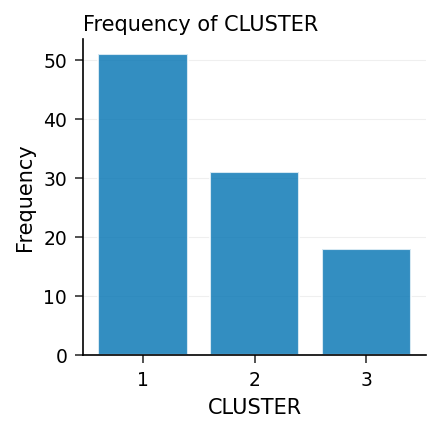

In [6]:
PROCEDURA FASTCLUS data=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    PROMĚNNÁ tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    NÁZEV 'Ohodnocení nového snímku z exportovaných centroidů';
SPUSTIT;

PROCEDURA ČETNOSTI data=rescored;
    TABLES CLUSTER / nocum;
    ŠTÍTEK CLUSTER='Shluk';
    NÁZEV 'Účastníci znovu ohodnoceni pomocí exportovaného modelu';
SPUSTIT;


## Interpretace výsledků

FASTCLUS odhalil tři chování odpovídající segmenty vložené do dat a profilovací tabulky je převádějí na retenční playbook. Čísla segmentů čtěte z tabulky *Segment Profiles* výše - označení shluků jsou libovolná, takže každou personu identifikujte podle jejího vzorce využívání:

- **Úsporní/hodnotoví uživatelé** - nízká spotřeba dat, skromné účty, delší doba trvání, velmi málo kontaktů s podporou, většinou na tarifu *Základní*. Tito zákazníci jsou stabilní a citliví na cenu; správným krokem je *chránit marži*, ne slevovat. Přiměřeně velký tarif zabrání šoku z účtu bez zbytečných dárků.
- **Datově náročné streamery** - vysoká spotřeba dat, vysoký počet hlasových a mezinárodních minut, prémiové účty, většinou *Neomezený*. Jsou loajální a vysoce hodnotní: strategií je *upsell a upgrade zařízení* spolu s proaktivní komunikací o kvalitě sítě, aby je konkurenční nabídka nemohla přetáhnout.
- **Kontaktní/rizikoví** - krátká doba trvání, zvýšený počet kontaktů s podporou, útraty ve střední úrovni. Časté kontakty s péčí spolu s krátkou dobou trvání jsou klasickými předzvěstmi odchodu. Toto je segment, který si zaslouží *proaktivní retenční nabídku* a následné obnovení služby.

Klíčové volby procedur, které to umožnily: **PROC STDIZE** zabránil tomu, aby velkoobjemové hlasové minuty přehlušily signál kontaktů s podporou; přehled pseudo-F odůvodnil počet shluků místo hádání; váha `FREQ` zajistila, aby se vícelinkové rodinné účty počítaly úměrně své velikosti; a cyklus `OUTSEED=`/`SEED=` exportoval centroidy, aby marketingový tým mohl přesegmentovat každý měsíční snímek jediným voláním FASTCLUS s `MAXITER=0` - bez nutnosti opětovného shlukování.
